In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from collections import deque

# Q7

## loading the data and suit it to meet the requirements in the question

In [2]:
df = pd.read_csv('recorded times.csv')
test_df = pd.read_csv('Test.csv')

In [3]:
# Group by 'Start', convert 'End' to set to remove duplicates, then convert to list
# Creating a map object where key is a name of a location and value is a list of locations accessible from that key directly
walk_trips = df.drop(df[df.Type == 'Car'].index ,axis=0).groupby('Start')['End'].apply(lambda x: list(set(x))).to_dict()
car_trips = df.drop(df[df.Type == 'Pedestrian'].index ,axis=0).groupby('Start')['End'].apply(lambda x: list(set(x))).to_dict()

### function that takes a date string and converts it to unix time integer

In [4]:
def minute_of_day(date_str):
    str_date = re.split(r'[/ :]', date_str) # use regex, seperate tokens with / : and whitespace
    int_date = [np.int64(numeric_string) for numeric_string in str_date] # convert to int
    _, _, _, hour, minutes = int_date # take only the relevant information
    return hour*60 + minutes # return time of day in minutes

### feature engineering, making sure everything is numerical

In [5]:
# turn date collumn to unix time (seconds)
df['Date'] = df['Date'].apply(lambda x: minute_of_day(x))
test_df['Date'] = test_df['Date'].apply(lambda x: minute_of_day(x))
#df['Trip'] = df['Start'] + df['End']

# create a set (no duplicates) of trips and types (pedestrian/car)
unique_Type = sorted(list(set(df['Type'])))
unique_locations = sorted(list(set(df['Start']).union(df['End'])))

# Create a mapping from locations/type names to numbers
Type_to_numbers_map = {Type: j for j, Type in enumerate(unique_Type)}
locations_to_number_map = {location: i for i, location in enumerate(unique_locations)}

# Replace city/type names with numbers in the DataFrame
df['Start'] = df['Start'].map(locations_to_number_map)
df['End'] = df['End'].map(locations_to_number_map)
df['Type'] = df['Type'].map(Type_to_numbers_map)

X = df.drop('Travel time', axis=1)

# get only pedestrians
t_pedest = df.drop(df[df.Type == 0].index, axis=0)
t_pedest = t_pedest['Travel time'].to_numpy()
t_pedest = t_pedest.reshape(len(t_pedest), 1)
X_pedest = X.drop(X[X.Type == 0].index, axis=0).drop('Type', axis=1).to_numpy()

# get only cars
t_cars = df.drop(df[df.Type == 1].index, axis=0)
t_cars = t_cars['Travel time'].to_numpy()
t_cars = t_cars.reshape(len(t_cars), 1)
X_cars = X.drop(X[X.Type == 1].index, axis=0).drop('Type', axis=1).to_numpy()

# car - 0 , pedestrian - 1

## create helper functions to train the regressor

### create X matrix according the polynomial degree

In [6]:
def create_X_matrix(X, d):
    X_matrix = np.ones((X.shape[0], 1))
    for degree in range(1, d + 1):
      X_matrix = np.hstack((X_matrix, X**degree))
    return X_matrix

### train the regressor and return the coefficients

In [7]:
def calc_w(X_matrix, t):
    return np.linalg.pinv(X_matrix.T@X_matrix)@X_matrix.T@t

### approximate and return t

In [8]:
def approx_t(X_matrix, w): 
    t_approx = np.zeros((len(X_matrix), 1))
    for sample in range(len(X_matrix)):
        t_approx[sample] += w.T@X_matrix[sample]
    return t_approx

In [9]:
def approx_t_single(X_matrix, w):
    t_approx = w.T@X_matrix
    return t_approx[0]

### calculate and return MSE for a set of samples

In [10]:
def calc_MSE(t_real, t_approx):
    return (np.sum((t_real - t_approx)**2))/len(t_real)

### cross validate (5 folds per degree) and find the best polynomial degree for the regressor

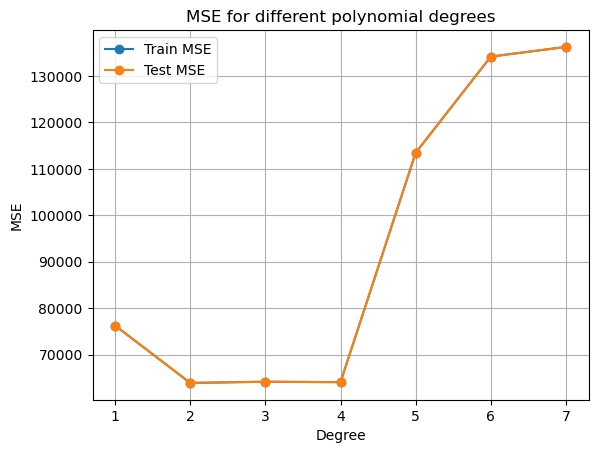

In [11]:
t_actual_min = t_pedest.min()
avg_train_MSE = []
avg_test_MSE = []
degrees = range(1, 8)
for d in degrees:
    train_MSE = []
    test_MSE = []
    for i in range(5):
        X_train, X_test, t_train, t_test = train_test_split(X_pedest, t_pedest, test_size=0.3)
        Xtrain_poly = create_X_matrix(X_train, d)
        Xtest_poly = create_X_matrix(X_test, d)
        w = calc_w(Xtrain_poly, t_train)
        t_approx_train = approx_t(Xtrain_poly, w)
        t_approx_test = approx_t(Xtest_poly, w)
        t_approx_train[t_approx_train < t_actual_min] = t_actual_min
        t_approx_test[t_approx_test < t_actual_min] = t_actual_min
        train_MSE.append(calc_MSE(t_train, t_approx_train))
        test_MSE.append(calc_MSE(t_test, t_approx_test))
    avg_train_MSE.append(np.mean(train_MSE))
    avg_test_MSE.append(np.mean(train_MSE))
plt.figure()
plt.plot(degrees, avg_train_MSE, '-o', label="Train MSE")
plt.plot(degrees, avg_test_MSE, '-o', label="Test MSE")
plt.title("MSE for different polynomial degrees")
plt.xlabel("Degree")
plt.ylabel("MSE")
plt.xticks(degrees)
plt.legend()
plt.grid()
plt.show()

## train the regressor for pedestrians

In [12]:
best_degree = 4
X_mat = create_X_matrix(X_pedest, best_degree)
w = calc_w(X_mat, t_pedest)
real_t_min = t_pedest.min()

## find and print best route for the test data for pedestrians

### using BFS search algorithm to find all viable routes and returning the best one and time it took to reach the destination

In [13]:
def find_best_route_bfs(graph, start_loc, end_loc, start_time_minutes):
    min_t = np.inf # starting best time is ∞
    best_path = []
    
    queue = deque([(start_loc, [start_loc], 0)]) # init queue (deque-Doubly Ended Queue)

    while queue: # continue while queue is not empty
        current_loc, path, current_t = queue.popleft()

        if current_loc == end_loc: # if we found a route
            if current_t < min_t: # update the best time and the path we found
                min_t = current_t
                best_path = path
            continue

        if current_loc not in graph: # if we have invalid location name break the loop
            break

        for node in graph[current_loc]: # for every path we can take from the current location
            if node not in path: # only if we have not visited this location yet in the current path (no loop)
                # map locations names to numbers
                start_num = locations_to_number_map[current_loc]
                end_num = locations_to_number_map[node]
                
                next_start_time = (start_time_minutes + current_t//60)%1440 # calc next start time in minutes (//is integer division)
                
                t_approximated = int(approx_t_single(create_X_matrix(np.array([[next_start_time, start_num, end_num]]), best_degree)[0], w))
                if t_approximated < real_t_min: # handle edge cases where t_approximates is too low or rarely negative
                    t_approximated = real_t_min
                
                next_t = current_t + t_approximated
                
                if next_t >= min_t:
                    continue
                queue.append((node, path + [node], next_t))

    if not best_path:
        best_path = ["Invalid starting location"]

    return [best_path, min_t]

### loop through the test data and print the results for pedestrians

In [14]:
print("Fastest route and approximate time for pedestrians for test data\n")
for i in range(len(test_df)):
    [best_path, min_t] = find_best_route_bfs(walk_trips, test_df['Origin'][i], test_df['Destination'][i], test_df['Date'][i])
    print(f"Origin: {test_df['Origin'][i]}, Destination: {test_df['Destination'][i]}")
    print(f"The best route is: {best_path}")
    print(f"Approximated travel time for route: {min_t} seconds\n")

Fastest route and approximate time for pedestrians for test data

Origin: Lanthanum, Destination: Barium
The best route is: ['Lanthanum', 'Barium']
Approximated travel time for route: 52 seconds

Origin: Lutetium, Destination: Niobium
The best route is: ['Lutetium', 'Terbium', 'Praseodymium', 'Iodine', 'Silver', 'Niobium']
Approximated travel time for route: 2797 seconds

Origin: Cadmium, Destination: Thallium
The best route is: ['Cadmium', 'Xenon', 'Neodymium', 'Dysprosium', 'Hafnium', 'Lutetium', 'Iridium', 'Bismuth', 'Lead', 'Thallium']
Approximated travel time for route: 4687 seconds



# Q8

## retrain the regressor for cars

In [15]:
best_degree = 4
X_mat = create_X_matrix(X_cars, best_degree)
w = calc_w(X_mat, t_cars)
real_t_min = t_cars.min()

## print results for people traveling by car

In [16]:
print("Fastest route and approximate time for cars for test data\n")
for i in range(len(test_df)):
    [best_path, min_t] = find_best_route_bfs(car_trips, test_df['Origin'][i], test_df['Destination'][i], test_df['Date'][i])
    print(f"Origin: {test_df['Origin'][i]}, Destination: {test_df['Destination'][i]}")
    print(f"The best route is: {best_path}")
    print(f"Approximated travel time for route: {min_t} seconds\n")

Fastest route and approximate time for cars for test data

Origin: Lanthanum, Destination: Barium
The best route is: ['Lanthanum', 'Barium']
Approximated travel time for route: 50 seconds

Origin: Lutetium, Destination: Niobium
The best route is: ['Lutetium', 'Terbium', 'Praseodymium', 'Iodine', 'Silver', 'Niobium']
Approximated travel time for route: 1339 seconds

Origin: Cadmium, Destination: Thallium
The best route is: ['Cadmium', 'Xenon', 'Neodymium', 'Dysprosium', 'Hafnium', 'Lutetium', 'Iridium', 'Bismuth', 'Lead', 'Thallium']
Approximated travel time for route: 2151 seconds



# Q9

## find best route for a mix of walking, car and bus

In [17]:
def bus_travel_time(bus_locations, forward, back, start_loc, end_loc, start_wait_time):
    if (start_loc not in bus_locations) or (end_loc not in bus_locations):
        return np.inf
    
    start_index = bus_locations.index(start_loc)
    end_index = bus_locations.index(end_loc)
    bus_arrival_time = start_wait_time
    if start_index < end_index:
        while bus_arrival_time not in forward[start_loc]:
            bus_arrival_time += 1
        return ((end_index - start_index)*4 + (bus_arrival_time - start_wait_time))*60
    
    while bus_arrival_time not in back[start_loc]:
            bus_arrival_time += 1
    return((start_index - end_index)*4 + (bus_arrival_time - start_wait_time))*60

In [18]:
def find_best_route_mixed(graph_walk, graph_car, start_loc, end_loc, start_time_minutes, w_walk, w_car):
    min_t = np.inf # starting best time is ∞
    best_path = []
    best_mode_of_transport = []
    # find leaving times for busses going back and forth
    bus_locations = ["Beryllium", "Neon", "Sulfur", "Titanium", "Nickel", "Selenium", "Zirconium",
        "Palladium", "Tellurium", "Cerium", "Gadolinium", "Ytterbium", "Osmium", "Lead", "Radium", "Plutonium"]
    forward = {}
    back = {}
    for i in range(len(bus_locations)-1):
        times = list(range((4*i)%10, 1441, 10))
        forward[bus_locations[i]] = times
        back[bus_locations[len(bus_locations) - 1 - i]] = times
    
    queue = deque([(start_loc, [start_loc], 0, [])]) # init queue (deque-Doubly Ended Queue)

    while queue: # continue while queue is not empty
        current_loc, path, current_t, mode_of_transport = queue.popleft()

        if current_loc == end_loc: # if we found a route
            if current_t < min_t: # update the best time and the path we found
                min_t = current_t
                best_path = path
                best_mode_of_transport = mode_of_transport
            continue
        
        if (current_loc not in graph_walk) & (current_loc not in graph_car): # if we have invalid location name break the loop
            break

        for node in set(graph_walk[current_loc]).union(graph_car[current_loc]): # for every path we can take from the current location
            if node not in path: # only if we have not visited this location yet in the current path (no loop)
                # map locations names to numbers
                start_num = locations_to_number_map[current_loc]
                end_num = locations_to_number_map[node]
                t_walk = np.inf
                t_car = np.inf
                t_bus = np.inf

                next_start_time = (start_time_minutes + current_t//60)%1440 # calc next start time in minutes (//is integer division)
                bus_extra_seconds = 60 - (start_time_minutes*60 + current_t)%60 # extra seconds to wait for the bus if minute is not round
                if bus_extra_seconds != 0:
                    t_bus = bus_travel_time(bus_locations, forward, back, current_loc, node, next_start_time+1) + bus_extra_seconds
                else:
                    t_bus = bus_travel_time(bus_locations, forward, back, current_loc, node, next_start_time)
                
                X = create_X_matrix(np.array([[next_start_time, start_num, end_num]]), best_degree)
                if node in graph_walk[current_loc]:
                    t_walk = int(approx_t_single(X[0], w_walk))
                if node in graph_car[current_loc]:
                    t_car = int(approx_t_single(X[0], w_car))
                
                if t_walk < real_t_min_walk: # handle edge cases where t_approximates is too low or rarely negative
                    t_walk = real_t_min_walk
                if t_car < real_t_min_cars: # handle edge cases where t_approximates is too low or rarely negative
                    t_car = real_t_min_cars

                best_current_t = min([t_walk, t_car, t_bus])
                next_t = current_t + best_current_t
                if next_t >= min_t:
                    continue
                current_transport_type = current_loc + " to " + node + " using "
                if best_current_t == t_walk:
                    current_transport_type += "walking"
                elif best_current_t == t_car:
                    current_transport_type += "car"
                else:
                    current_transport_type += "bus"
                queue.append((node, path + [node], next_t, mode_of_transport + [current_transport_type]))

    if not best_path:
        best_path = ["Invalid starting location"]

    return [best_path, min_t, best_mode_of_transport]

In [19]:
best_degree = 4
X_mat_pedest = create_X_matrix(X_pedest, best_degree)
w_walk = calc_w(X_mat_pedest, t_pedest)
real_t_min_walk = t_pedest.min()
X_mat_cars = create_X_matrix(X_cars, best_degree)
w_cars = calc_w(X_mat_cars, t_cars)
real_t_min_cars = t_pedest.min()

In [20]:
print("Fastest route and approximate time for mixed transport for test data\n")
for i in range(len(test_df)):
    [best_path, min_t, best_transport] = find_best_route_mixed(walk_trips, car_trips, test_df['Origin'][i], test_df['Destination'][i], test_df['Date'][i], w_walk, w_cars)
    print(f"Origin: {test_df['Origin'][i]}, Destination: {test_df['Destination'][i]}")
    print(f"The best route is: {best_path}")
    print(f"Transportation route was: {best_transport}")
    print(f"Approximated travel time for route: {min_t} seconds\n")

Fastest route and approximate time for mixed transport for test data

Origin: Lanthanum, Destination: Barium
The best route is: ['Lanthanum', 'Barium']
Transportation route was: ['Lanthanum to Barium using walking']
Approximated travel time for route: 52 seconds

Origin: Lutetium, Destination: Niobium
The best route is: ['Lutetium', 'Terbium', 'Praseodymium', 'Iodine', 'Silver', 'Niobium']
Transportation route was: ['Lutetium to Terbium using car', 'Terbium to Praseodymium using car', 'Praseodymium to Iodine using car', 'Iodine to Silver using car', 'Silver to Niobium using car']
Approximated travel time for route: 1339 seconds

Origin: Cadmium, Destination: Thallium
The best route is: ['Cadmium', 'Xenon', 'Neodymium', 'Dysprosium', 'Hafnium', 'Lutetium', 'Iridium', 'Bismuth', 'Lead', 'Thallium']
Transportation route was: ['Cadmium to Xenon using car', 'Xenon to Neodymium using car', 'Neodymium to Dysprosium using car', 'Dysprosium to Hafnium using car', 'Hafnium to Lutetium using car'